In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)

print(f" TensorFlow version: {tf.__version__}")

 TensorFlow version: 2.19.0


In [5]:
BASE = "./"

X_train = pd.read_csv(BASE + "outputs/X_train.csv").values  # .values → converts to numpy array
X_test  = pd.read_csv(BASE + "outputs/X_test.csv").values
y_train = pd.read_csv(BASE + "outputs/y_train.csv").squeeze().values
y_test  = pd.read_csv(BASE + "outputs/y_test.csv").squeeze().values

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"Classes       : {np.unique(y_train, return_counts=True)}")

X_train shape : (763, 42)
X_test shape  : (191, 42)
Classes       : (array([0, 1]), array([381, 382]))


In [6]:
def build_ann(input_dim):
    model = keras.Sequential([
        # --- Input Layer ---
        layers.Input(shape=(input_dim,)),
        
        # --- Hidden Layer 1: 256 neurons ---
        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),   # stabilizes learning speed
        layers.Dropout(0.4),           # randomly drops 40% neurons each step

        # --- Hidden Layer 2: 128 neurons ---
        layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # --- Hidden Layer 3: 64 neurons ---
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),

        # --- Output Layer: 1 neuron → probability 0 to 1 ---
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_ann(X_train.shape[1])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │          11,008 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 53,761 (210.00 KB)

 Trainable params: 52,993 (207.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
print(" Model compiled")

 Model compiled


In [8]:
os.makedirs("../models", exist_ok=True)

cb_early_stop = callbacks.EarlyStopping(
    monitor='val_auc', patience=15,
    restore_best_weights=True, mode='max', verbose=1
)

cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=7, min_lr=1e-6, verbose=1
)

cb_checkpoint = callbacks.ModelCheckpoint(
    filepath='../models/ann_best_model.keras',
    monitor='val_auc', save_best_only=True,
    mode='max', verbose=0
)

print("Callbacks ready")

Callbacks ready


In [9]:
print(" Training ANN...")

history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.15,
    callbacks=[cb_early_stop, cb_reduce_lr, cb_checkpoint],
    verbose=1
)

print(f"\n Training complete! Stopped at epoch: {len(history.history['loss'])}")

 Training ANN...
Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.5272 - auc: 0.5426 - loss: 1.1854 - val_accuracy: 0.6870 - val_auc: 0.7797 - val_loss: 0.8410 - learning_rate: 0.0010
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6420 - auc: 0.7255 - loss: 0.8968 - val_accuracy: 0.7130 - val_auc: 0.7832 - val_loss: 0.8161 - learning_rate: 0.0010
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7198 - auc: 0.8080 - loss: 0.7740 - val_accuracy: 0.7130 - val_auc: 0.7779 - val_loss: 0.8100 - learning_rate: 0.0010
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7240 - auc: 0.8126 - loss: 0.7801 - val_accuracy: 0.7217 - val_auc: 0.7917 - val_loss: 0.7969 - learning_rate: 0.0010
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7240 - auc: 0.7934 - loss: 0.8407 - val_accuracy: 0.7391 - val_auc: 0.7939 - val_loss: 0.7852 - learning_rate: 0.0010
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0

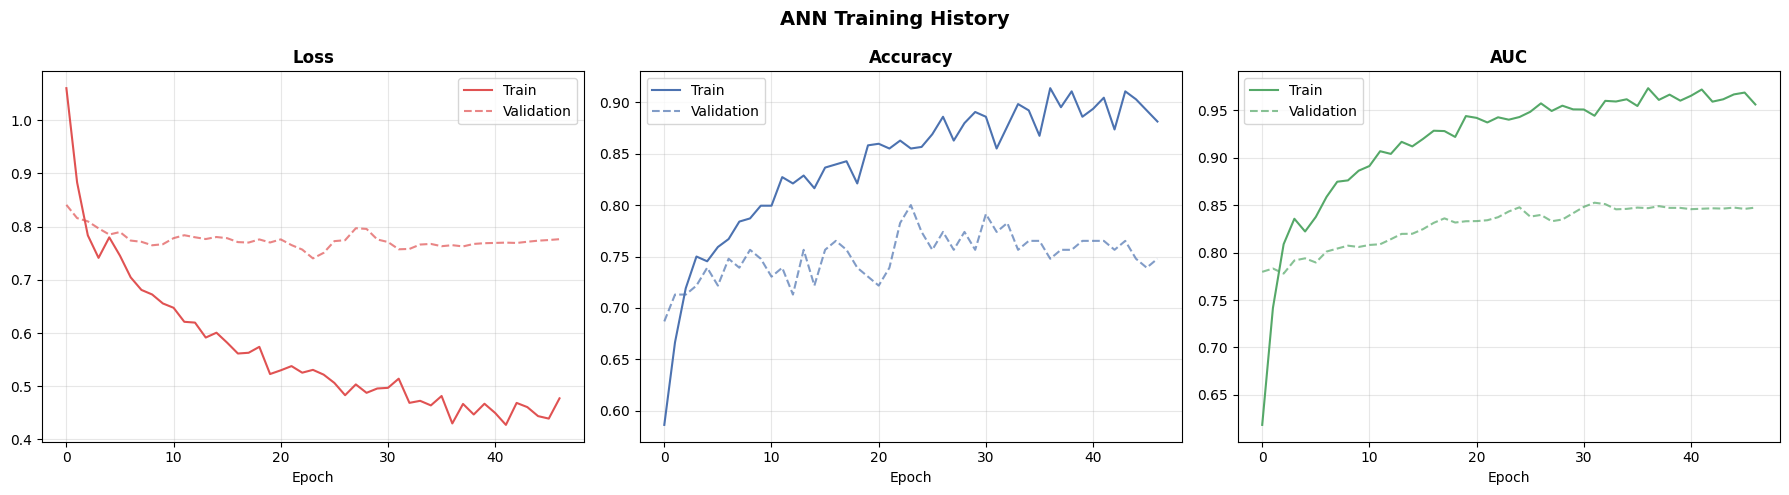

 Saved plot 16


In [10]:
os.makedirs("../outputs/plots", exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("ANN Training History", fontsize=14, fontweight='bold')

metrics_to_plot = [
    ('loss',     'val_loss',     'Loss',     '#E05252'),
    ('accuracy', 'val_accuracy', 'Accuracy', '#4C72B0'),
    ('auc',      'val_auc',      'AUC',      '#55A868'),
]

for ax, (train_m, val_m, title, color) in zip(axes, metrics_to_plot):
    ax.plot(history.history[train_m], label='Train', color=color)
    ax.plot(history.history[val_m],  label='Validation', color=color, linestyle='--', alpha=0.7)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/plots/16_ann_training_history.png", dpi=150)
plt.show()
print(" Saved plot 16")

In [11]:
y_proba_ann = model.predict(X_test).flatten()
y_pred_ann  = (y_proba_ann >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred_ann)
auc = roc_auc_score(y_test, y_proba_ann)

print("=" * 45)
print(f"  ANN TEST RESULTS")
print("=" * 45)
print(f"  Accuracy  : {acc:.4f}")
print(f"  ROC-AUC   : {auc:.4f}")
print("=" * 45)
print("\n Classification Report:")
print(classification_report(y_test, y_pred_ann, target_names=["Closed", "Acquired"]))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
  ANN TEST RESULTS
  Accuracy  : 0.7853
  ROC-AUC   : 0.8803

 Classification Report:
              precision    recall  f1-score   support

      Closed       0.77      0.82      0.79        96
    Acquired       0.81      0.75      0.78        95

    accuracy                           0.79       191
   macro avg       0.79      0.79      0.78       191
weighted avg       0.79      0.79      0.79       191



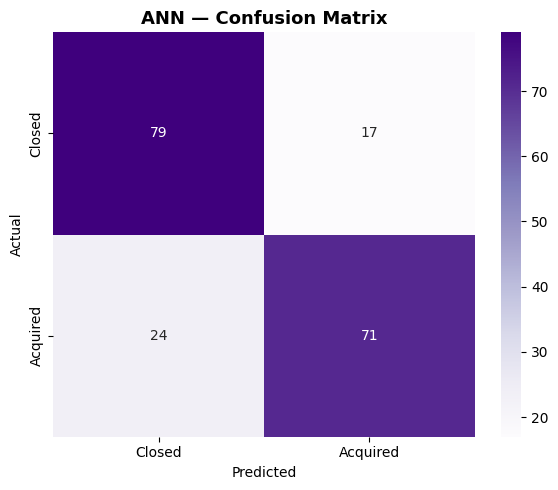

In [12]:
cm = confusion_matrix(y_test, y_pred_ann)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=["Closed","Acquired"],
            yticklabels=["Closed","Acquired"], ax=ax)
ax.set_title("ANN — Confusion Matrix", fontsize=13, fontweight='bold')
ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
plt.tight_layout()
plt.savefig("../outputs/plots/17_ann_confusion_matrix.png", dpi=150)
plt.show()

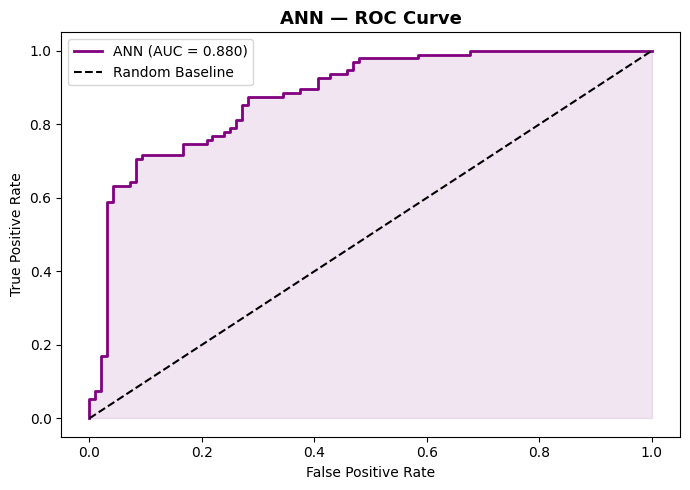

Saved plot 18


In [13]:
fpr, tpr, _ = roc_curve(y_test, y_proba_ann)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='purple', lw=2, label=f"ANN (AUC = {auc:.3f})")
ax.plot([0,1],[0,1],'k--', label="Random Baseline")
ax.fill_between(fpr, tpr, alpha=0.1, color='purple')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ANN — ROC Curve", fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/plots/18_ann_roc_curve.png", dpi=150)
plt.show()
print("Saved plot 18")

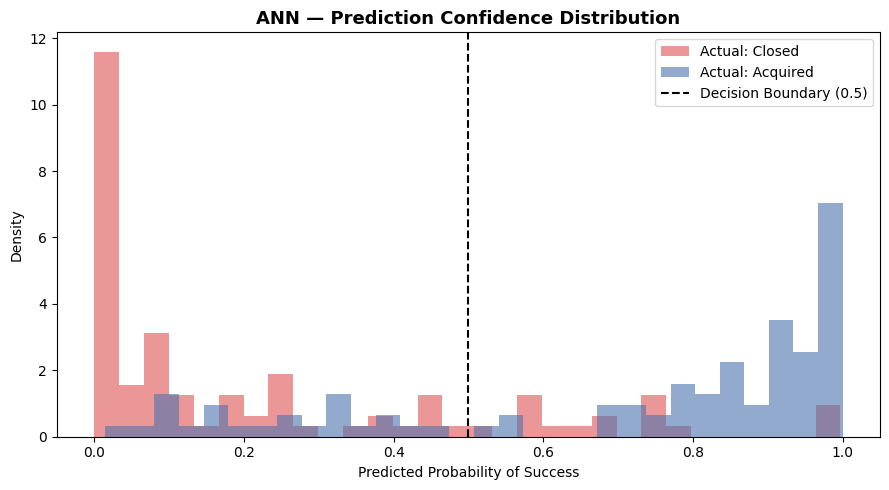

Saved plot 19


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(y_proba_ann[y_test == 0], bins=30, alpha=0.6,
        color='#E05252', label='Actual: Closed', density=True)
ax.hist(y_proba_ann[y_test == 1], bins=30, alpha=0.6,
        color='#4C72B0', label='Actual: Acquired', density=True)
ax.axvline(0.5, color='black', linestyle='--', label='Decision Boundary (0.5)')
ax.set_xlabel("Predicted Probability of Success")
ax.set_ylabel("Density")
ax.set_title("ANN — Prediction Confidence Distribution", fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/plots/19_ann_confidence.png", dpi=150)
plt.show()
print("Saved plot 19")

In [15]:
import json

ann_results = {
    "model": "ANN",
    "accuracy": round(float(acc), 4),
    "roc_auc":  round(float(auc), 4),
    "epochs_trained": len(history.history['loss'])
}

with open("../outputs/ann_results.json", "w") as f:
    json.dump(ann_results, f, indent=2)

print(" ANN results saved to outputs/ann_results.json")
print(f"\n Final Summary:")
print(f"   Accuracy     : {acc:.4f}")
print(f"   ROC-AUC      : {auc:.4f}")
print(f"   Epochs Ran   : {len(history.history['loss'])}")
print(f"   Model File   : models/ann_best_model.keras")

 ANN results saved to outputs/ann_results.json

 Final Summary:
   Accuracy     : 0.7853
   ROC-AUC      : 0.8803
   Epochs Ran   : 47
   Model File   : models/ann_best_model.keras
